In [1]:
import numpy as np

## Step 1: Initialize Weights and Bias
- We begin by setting initial values. Each input weight and the bias term are initialized, often to 0. These values are updated during training. They are the parameters that the perceptron will learn.


In [4]:
# initialize bias and weights
def initialize_weights(n_features):
    weights = np.zeros(n_features)
    bias = 0
    return weights, bias

## Step 2: Define the Activation Function
- The activation function decides the final output of the perceptron. For binary classification, a simple step function is used:
- Output is 1 if the input ≥ 0
- Otherwise, output is 0


In [5]:
def step_function(z):
    return 1 if z >= 0 else 0

## Step 3: Compute Weighted Sum and  Apply Activation
- A perceptron computes a weighted sum of the inputs with a bias to form a linear decision value, which is then passed through an activation function to produce a final binary output (0 or 1).

In [6]:
def predict(x, weights, bias):
    z = np.dot(x, weights) + bias
    return step_function(z)

## Step 4: Update Weights and Bias
- After comparing the prediction with the actual output, we adjust weights and bias if the prediction is incorrect. This is done using the perceptron learning rule, which guides how the model learns from its mistakes.

In [7]:
def update_weights(weights, bias, xi, target, prediction, learning_rate):
    error = target - prediction
    weights += learning_rate * error * xi
    bias += learning_rate * error
    return weights, bias

## Step 5: Define Training function
- The perceptron learns by iterating over the training data (epochs), making predictions, comparing with actual outputs, and updating weights and bias to gradually reduce errors and form the correct decision boundary.

In [8]:
# Training function (loop over epochs and data)
def train_perceptron(X, y, learning_rate=0.1, epochs=10):
    n_samples, n_features = X.shape
    weights, bias = initialize_weights(n_features)

    for epoch in range(epochs):
        for xi, target in zip(X, y):
            prediction = predict(xi, weights, bias)
            weights, bias = update_weights(weights, bias, xi, target, prediction, learning_rate)

    return weights, bias

## Step 6: Final prediction function
- After training is complete, this step is used to make predictions on new or test data. It applies the learned weights and bias to each input sample and returns the predicted outputs.

In [11]:
def predict_all(X, weights, bias):
    return [predict(x, weights, bias) for x in X]

# XOR Problem
- Earlier, we explored how a single-layer perceptron can learn simple logical functions like AND and OR because their outputs can be separated by a straight line. Now, let us explore a more complex case: the XOR problem.
- A single-layer perceptron performs well for linearly separable problems. This means the data can be divided using a straight line. However, XOR is a classic example of a problem that is not linearly separable. This makes it impossible for a simple perceptron to classify the data correctly.
- When we try to train a perceptron on the XOR gate, the model fails to produce accurate predictions. The reason is that the decision boundary generated by the model is a straight line, which cannot correctly split the outputs of the XOR function.



In [12]:
# AND Gate
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])

# OR Gate
X_or = np.array([[0,0], [0,1], [1,0], [1,1]])
y_or = np.array([0, 1, 1, 1])

In [13]:
# Train Perceptron on AND
weights_and, bias_and = train_perceptron(X_and, y_and)
predictions_and = predict_all(X_and, weights_and, bias_and)

# Train Perceptron on OR
weights_or, bias_or = train_perceptron(X_or, y_or)
predictions_or = predict_all(X_or, weights_or, bias_or)

In [14]:
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, weights, bias, title):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = np.array([step_function(np.dot(x, weights) + bias) for x in grid])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    # Separate plotting for clarity and legend
    class_0 = X[y == 0]
    class_1 = X[y == 1]

    plt.scatter(class_0[:, 0], class_0[:, 1], color='blue', edgecolors='k', label='0')
    plt.scatter(class_1[:, 0], class_1[:, 1], color='red', edgecolors='k', label='1')

    plt.legend(title="Output Class", fontsize=8, title_fontsize=9)
    plt.title(title)
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.grid(True)
    plt.show()

In [15]:
import pandas as pd
from IPython.display import display


# Create prediction tables for AND, OR, XOR
df_and = pd.DataFrame({
    "x₁": X_and[:, 0],
    "x₂": X_and[:, 1],
    "Actual": y_and,
    "Predicted": predictions_and
})

df_or = pd.DataFrame({
    "x₁": X_or[:, 0],
    "x₂": X_or[:, 1],
    "Actual": y_or,
    "Predicted": predictions_or
})

print("AND Gate Prediction Results:")
display(df_and)

print("\nOR Gate Prediction Results:")
display(df_or)

AND Gate Prediction Results:


,x₁,x₂,Actual,Predicted
0,0,0,0,0
1,0,1,0,0
2,1,0,0,0
3,1,1,1,1



OR Gate Prediction Results:


,x₁,x₂,Actual,Predicted
0,0,0,0,0
1,0,1,1,1
2,1,0,1,1
3,1,1,1,1


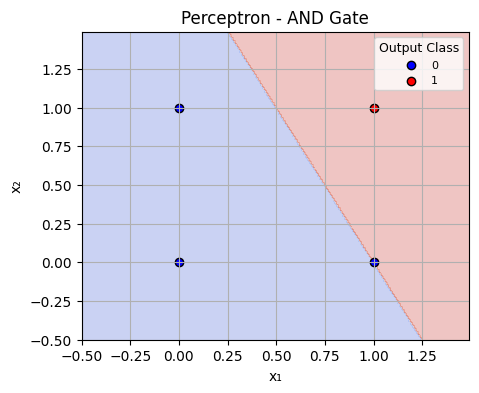

In [16]:
plot_decision_boundary(X_and, y_and, weights_and, bias_and, "Perceptron - AND Gate")

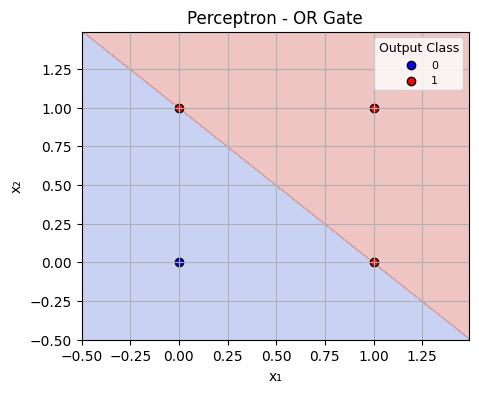

In [17]:
plot_decision_boundary(X_or, y_or, weights_or, bias_or, "Perceptron - OR Gate")

# The Solution: Hidden Layers
- To solve problems like XOR, we need a model that can:
- Create multiple lines, or Learn combinations of features to form complex decision boundaries (like curves or regions).
This is where hidden layers come in:
- By adding a hidden layer, the model can learn intermediate representations of the data.
- These layers transform the input space in such a way that the final layer can separate the transformed points using a line.
- In the case of XOR, a hidden layer can:
- Learn a rule like “input bits are different”
- And pass that to the output layer for final classification.

# Limitations of Perceptrons
A perceptron is a fundamental building block in neural networks, but it has several limitations that prevent it from solving complex real-world problems effectively.
1. Cannot solve non-linear problems
    - Perceptrons fail on tasks like XOR, where data isn't linearly separable.
2. Limited representational power
    - They can't capture complex patterns due to their simple structure.
3. No hidden layers
    - Without hidden layers, they can't learn hierarchical or abstract features.
4. Linear output space
    - The output is restricted to simple linear boundaries.
5. Limited real-world use
    - They are ineffective for tasks requiring deeper understanding or flexibility.

# From Perceptron to MLP
- A perceptron with just input and output nodes is too simple.
- Once we add a hidden layer, it becomes a Multi-Layer Perceptron (MLP).
- An MLP overcomes the limitation of linear separability by: 
    a. Stacking layers.
    b. Using non-linear activations (sigmoid, tanh, ReLU).